In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.preprocessing import StandardScaler
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [137]:
import os
import kagglehub
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score,recall_score,precision_score

Loading the dataset

In [138]:
path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")

# 2. Point to the train and test CSV files inside the directory
train_path = os.path.join(path, "train.csv")
test_path = os.path.join(path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.


In [139]:
print(f"Train Shape: {train_df.shape} | Test Shape: {test_df.shape}")

# 3. Separate features and targets (Drop target and subject identifier)
X_train = train_df.drop(columns=['Activity', 'subject'])
y_train = train_df['Activity']

X_test = test_df.drop(columns=['Activity', 'subject'])
y_test = test_df['Activity']

Train Shape: (7352, 563) | Test Shape: (2947, 563)


In [140]:
total_activities=pd.concat([y_train,y_test],axis=0).value_counts()

In [141]:
total_activities=pd.DataFrame(total_activities)

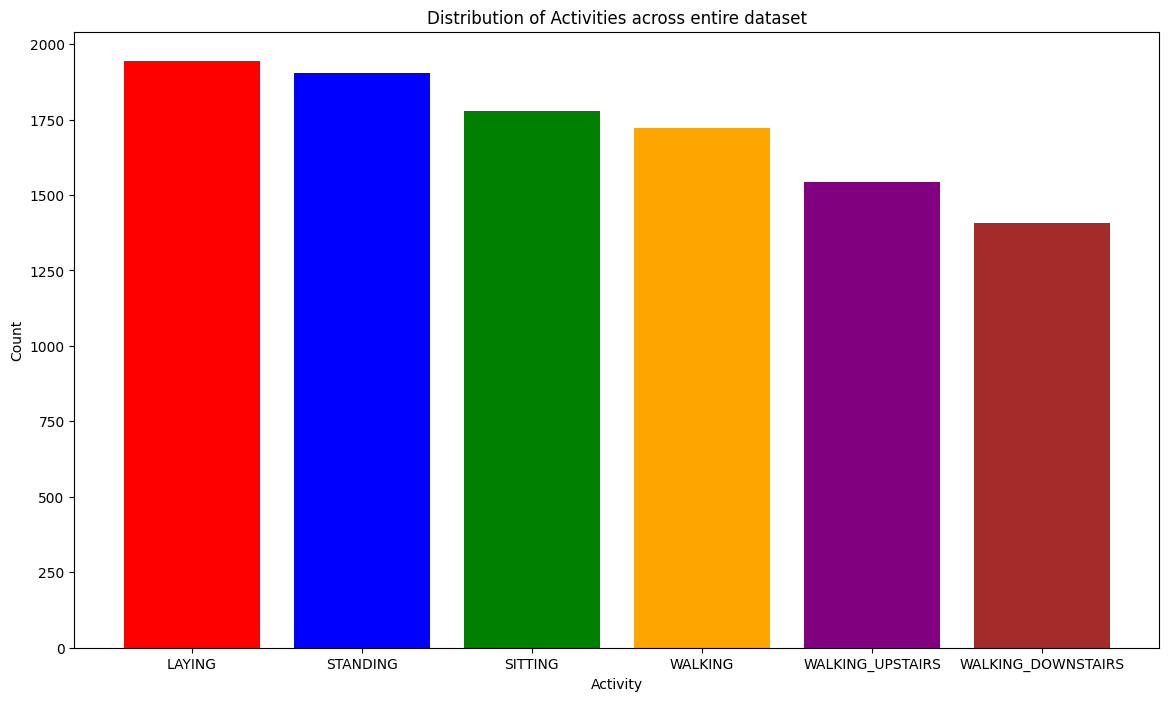

In [142]:
plt.figure(figsize=(14,8))
plt.bar(list(total_activities.index),total_activities['count'],color=['red', 'blue', 'green', 'orange', 'purple', 'brown'])
plt.title('Distribution of Activities across entire dataset')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.show()

In [143]:
#encoder=LabelEncoder()
#y_train=encoder.fit_transform(y_train)
#y_test=encoder.transform(y_test)

In [144]:
import numpy as np

class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.eigenvalues = None
        self.mean = None

    def fit(self, X):
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Compute the covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Compute the eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvalues and eigenvectors
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        self.eigenvalues=eigenvalues
        eigenvectors = eigenvectors[:, sorted_idx]

        # Select the top n_components
        self.components = eigenvectors[:, :self.n_components]

    def transform(self, X,components):
        # Project data onto principal components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components[:,:components])

    def inverse_transform(self, X_reduced):
        # Reconstruct original data from principal components
        return np.dot(X_reduced, self.components.T) + self.mean

In [145]:
X_train=X_train.to_numpy()
X_test=X_test.to_numpy()

In [146]:
pca=PCAFromScratch(n_components=100)
pca.fit(X_train)

In [147]:
sum=np.sum(pca.eigenvalues)

In [148]:
explained_variance_ratio=np.cumsum(pca.eigenvalues/sum)

In [149]:
components_min_required=np.argmax(explained_variance_ratio>0.9)+1

In [150]:
components_min_required

np.int64(34)

Hence to explain 90 percent information(means 90 percent variance of data) we do not require 561 features,within 34 transformed features 90 percent of information can be explained

In [151]:
X_train_reduced=pca.transform(X_train,components_min_required)

In [152]:
X_train_reduced.shape

(7352, 34)

In [153]:
X_test_reduced=pca.transform(X_test,components_min_required)

In [154]:
X_test_reduced.shape

(2947, 34)

Now to fit the target data into softmax classifier lets convert target into one hot encoded format

In [155]:
encoder=OneHotEncoder()
encoder.fit(y_train.values.reshape(-1,1))
y_train_encoded=encoder.transform(y_train.values.reshape(-1,1)).toarray()
y_test_encoded=encoder.transform(y_test.values.reshape(-1,1)).toarray()

In [156]:
feature_names=encoder.get_feature_names_out()

In [157]:
y_train_encoded.shape

(7352, 6)

Now we generate the validation data by splitting the training data

In [158]:
#Train validation set
X_train_reduced, X_val_reduced, y_train_encoded, y_val_encoded = train_test_split(X_train_reduced,y_train_encoded, test_size=0.2, random_state=101)

In [159]:
#Adding the intercept as first column of X_train
X_train_reduced = np.c_[np.ones((X_train_reduced.shape[0], 1)), X_train_reduced]
X_val_reduced  = np.c_[np.ones((X_val_reduced.shape[0], 1)), X_val_reduced]
X_test_reduced = np.c_[np.ones((X_test_reduced.shape[0], 1)), X_test_reduced]

Training Phase and custom implementation of the model

In [160]:
class SoftmaxRegression :
    def __init__(self,learning_rate,iterations) :
        self.theta=None
        self.iterations=iterations
        self.learning_rate=learning_rate
        self.Val_error=[] #This will keep track of all validation errors in each iteration
        self.Training_error=[] #This will keep track of all training errors in each iteration


    def fit(self,X_train,X_val,y_train,y_val) :
        m,n=X_train.shape #X_train is already biased
        self.theta=np.zeros((n,y_train.shape[1])) #n is the number of features and second parameter is number of classes
        for p in range(self.iterations) :
            prob_train = self.probability_matrix(X_train,self.theta)
            error_train=prob_train-y_train
            #Gradient of cross entropy
            gradient=X_train.T.dot(error_train)/m

            #Updating the parameters
            self.theta-=self.learning_rate*gradient

            #Calculating the loss
            loss_train = self.entropy_loss(y_train, prob_train)
            self.Training_error.append(loss_train)

            #Storing the validation loss
            prob_validation=self.probability_matrix(X_val,self.theta)
            loss_validation=self.entropy_loss(y_val,prob_validation)
            self.Val_error.append(loss_validation)

    def predict(self,X) :
        prob= self.probability_matrix(X,self.theta)
        return np.argmax(prob, axis=1)

    def entropy_loss(self, Y_true, Y_pred):
        m = Y_true.shape[0]
        return -np.sum(Y_true * np.log(Y_pred + 1e-15)) / m  # 1e-15 is tiny constant which ensures that log will not give inf

   # This will calculate the probability of all samples belonging to 6 classes
   # One row will have 6 columns which will show the probability that it belongs to that specific class
    def probability_matrix(self, X, theta):
        Z = X.dot(theta)
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [161]:
SR=SoftmaxRegression(0.01,1000)

In [162]:
SR.fit(X_train_reduced,X_val_reduced,y_train_encoded,y_val_encoded)

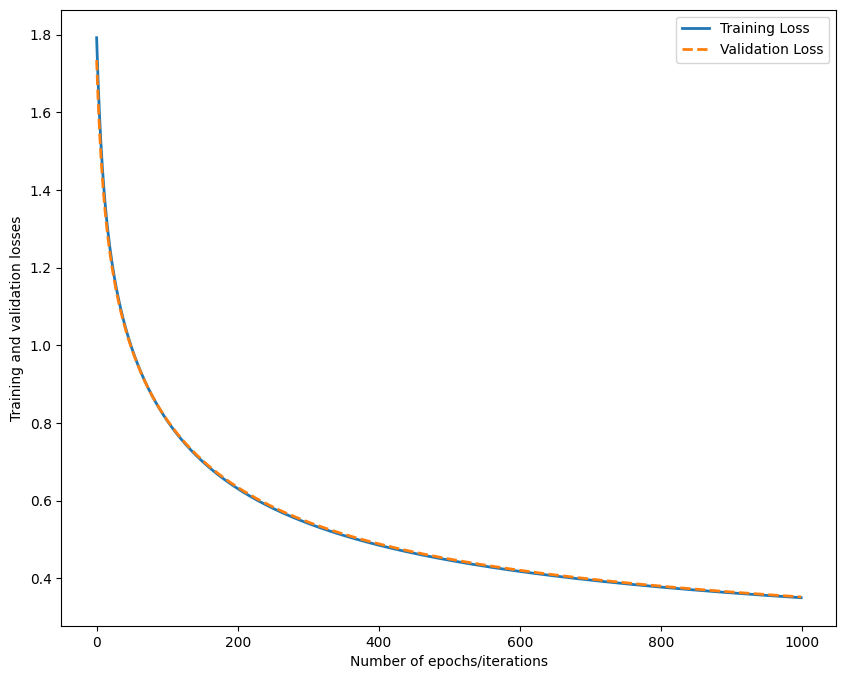

In [163]:
plt.figure(figsize=(10, 8))

plt.plot(SR.Training_error, label='Training Loss', linewidth=2)
plt.plot(SR.Val_error, label='Validation Loss', linestyle='--', linewidth=2)
plt.xlabel('Number of epochs/iterations')
plt.ylabel('Training and validation losses')
plt.legend()
plt.show()

In [164]:
predictions=SR.predict(X_test_reduced)

In [165]:
y_test=np.argmax(y_test_encoded,axis=1)

In [166]:
y_test

array([2, 2, 2, ..., 5, 5, 5])

In [167]:
predictions

array([2, 2, 2, ..., 5, 5, 3])

Classificationn report and confusion matrix of custom implementation of Softmax regressor

Confusion Matrix of our own model


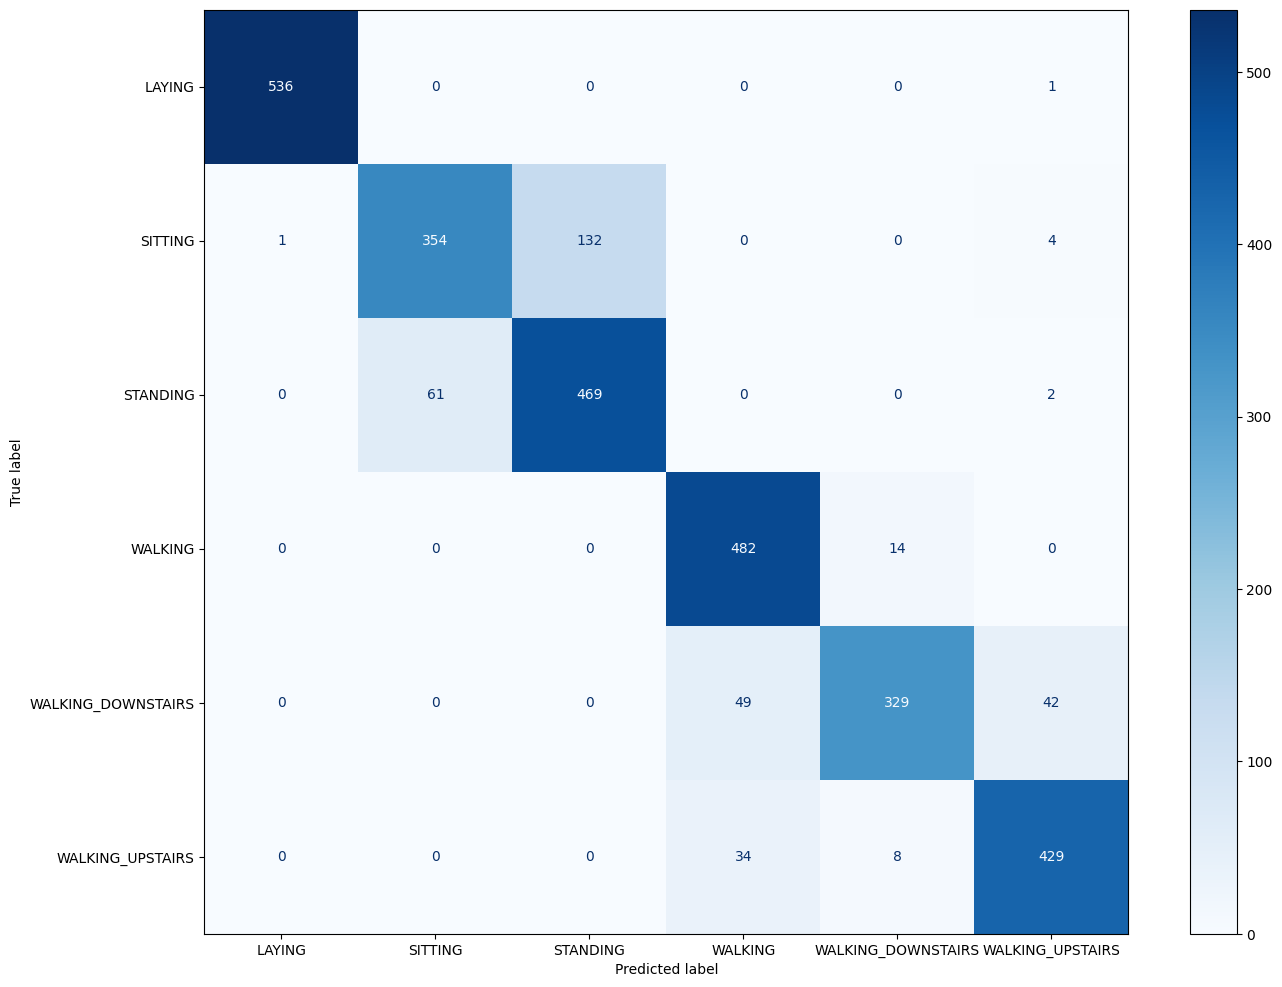

In [204]:
print('Confusion Matrix of our own model')
fig,ax=plt.subplots(figsize=(16,12))
cm=confusion_matrix(y_test,predictions)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[word[3:] for word in feature_names])
display.plot(ax=ax,cmap=plt.cm.Blues)
plt.show()

In [206]:
print('Classification report of custom softmax regressor')
print(classification_report(y_test,predictions))


Classification report of custom softmax regressor
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.85      0.72      0.78       491
           2       0.78      0.88      0.83       532
           3       0.85      0.97      0.91       496
           4       0.94      0.78      0.85       420
           5       0.90      0.91      0.90       471

    accuracy                           0.88      2947
   macro avg       0.89      0.88      0.88      2947
weighted avg       0.89      0.88      0.88      2947



In [170]:
accuracy=accuracy_score(y_test,predictions)
recall=recall_score(y_test,predictions,average='weighted')
precision=precision_score(y_test,predictions,average='weighted')
print(f"The accuracy of the custom implementation of model is {accuracy:.4f}")
print(f"The precision of the custom implementation of model is {precision:.4f}")
print(f"The recall of the custom implementation of model is {recall:.4f}")


The accuracy of the custom implementation of model is 0.8819
The precision of the custom implementation of model is 0.8855
The recall of the custom implementation of model is 0.8819


In [171]:
from sklearn.linear_model import LogisticRegression

In [172]:
LR=LogisticRegression(penalty=None,max_iter=1000)

In [173]:
X_train = X_train[:, 1:] #We are removing intercept because in sklearn model we wont need them
X_test = X_test[:, 1:]
LR.fit(X_train,y_train)
sklearn_pred=LR.predict(X_test)

In [174]:
sklearn_pred=np.argmax(encoder.transform(sklearn_pred.reshape(-1,1)).toarray(),axis=1)

Confusion matrix and classification report of Sklearn model

Confusion Matrix of sklearn model


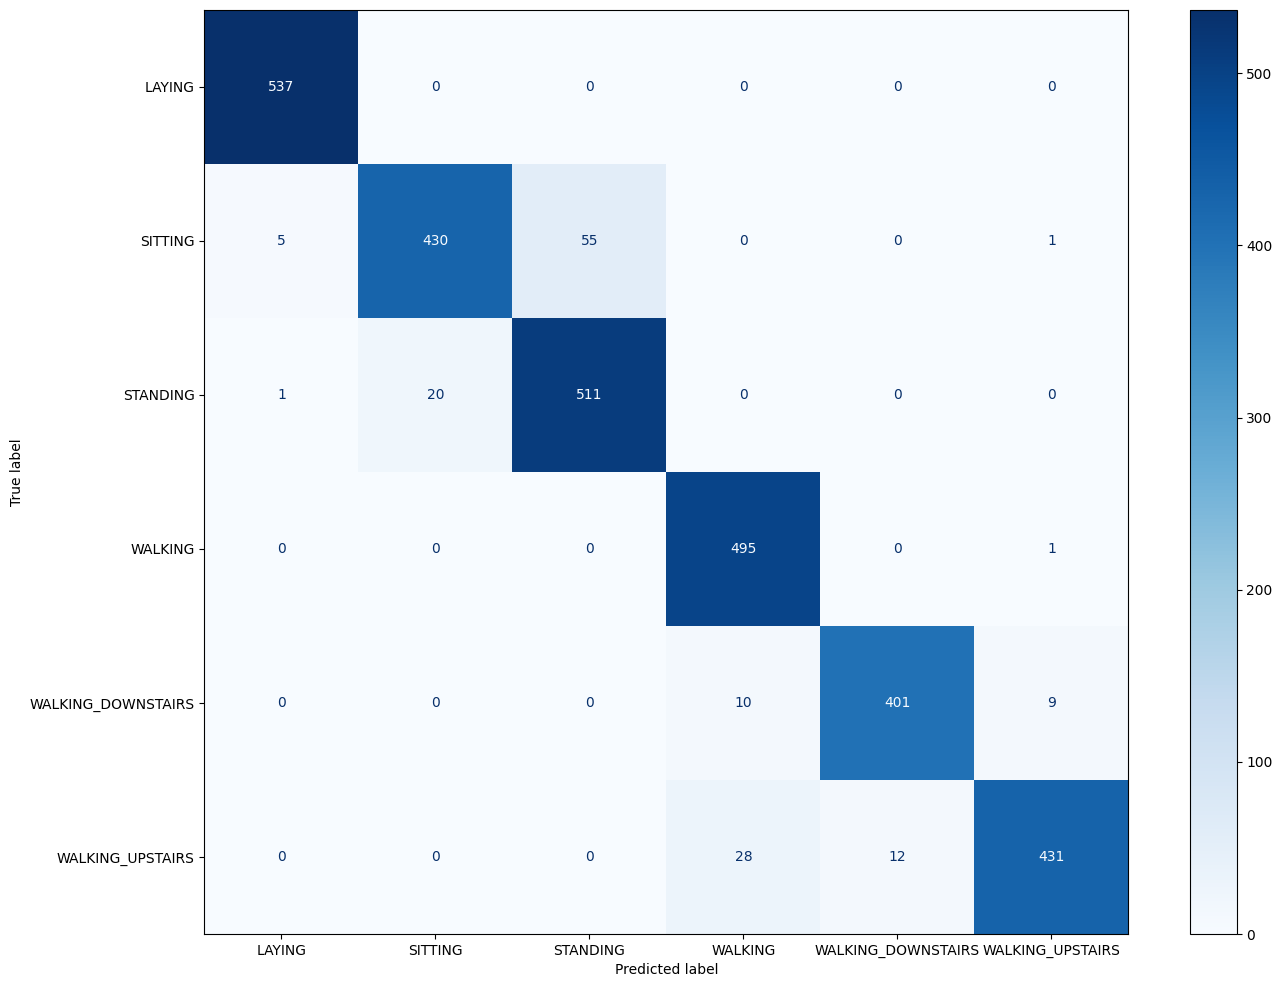

In [203]:
print('Confusion Matrix of sklearn model')
fig,ax=plt.subplots(figsize=(16,12))
cm=confusion_matrix(y_test,sklearn_pred)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[word[3:] for word in feature_names])
display.plot(ax=ax,cmap=plt.cm.Blues)
plt.show()

In [207]:
print('Classification report of sklearn model')
print(classification_report(y_test,sklearn_pred))

Classification report of sklearn model
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       537
           1       0.96      0.88      0.91       491
           2       0.90      0.96      0.93       532
           3       0.93      1.00      0.96       496
           4       0.97      0.95      0.96       420
           5       0.98      0.92      0.94       471

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



In [208]:
accuracy=accuracy_score(y_test,sklearn_pred)
recall=recall_score(y_test,sklearn_pred,average='weighted')
precision=precision_score(y_test,sklearn_pred,average='weighted')
print(f"The accuracy of the sklearn model is {accuracy:.4f}")
print(f"The precision of the sklearn model is {precision:.4f}")
print(f"The recall of the sklearn model is {recall:.4f}")

The accuracy of the sklearn model is 0.9518
The precision of the sklearn model is 0.9529
The recall of the sklearn model is 0.9518
